# XGBClassifier auf Porto Seguro – kompakte Anwendung

Dieses Notebook trainiert und optimiert einen `XGBClassifier` auf Porto Seguro's Safe
Driver Prediction (OpenML ID 42742). Der Aufbau ist bewusst kompakt und auf den fairen
Vergleich mit der logistischen Regression ausgerichtet.

Enthalten sind:

1. identische Datenaufbereitung und Split-Indizes wie bei der LogReg,
2. eine XGBoost-Baseline,
3. ein kleiner Sensitivitätscheck zentraler Hyperparameter,
4. eine kompakte `RandomizedSearchCV`,
5. 5-Fold-Cross-Validation des ausgewählten Modells,
6. finale Testbewertung mit ROC-AUC, Gini und Average Precision,
7. ROC-/Precision-Recall-Kurve und Gain-basierte Feature Importance.

Der Testsplit bleibt bis zum Abschluss der Modellauswahl unberührt.


## 1. Setup


In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform, loguniform
from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)
from xgboost import XGBClassifier

SEED = 42

# Normaler Lauf: methodisch aussagekräftige Einstellungen.
# Für einen kurzen technischen Test vorab kann SCHNELLLAUF=True gesetzt werden.
SCHNELLLAUF = os.getenv("XGB_SCHNELLLAUF", "0") == "1"
EXP_FRAC = 0.03 if SCHNELLLAUF else 0.15
SEARCH_FRAC = 0.03 if SCHNELLLAUF else 0.25
N_ITER = 2 if SCHNELLLAUF else 20
SEARCH_CV_SPLITS = 2 if SCHNELLLAUF else 3
FINAL_CV_SPLITS = 2 if SCHNELLLAUF else 5

ABB_DIR = Path("xgbclassifier_anwendung_abbildungen")
ABB_DIR.mkdir(exist_ok=True)

def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1

print("Schnelllauf:", SCHNELLLAUF)


Schnelllauf: False


## 2. Daten laden und aufbereiten


In [2]:
t0 = time.time()
df = fetch_openml(data_id=42742, as_frame=True).frame
df["target"] = df["target"].astype(str).astype(float).astype(int)

# Die laufende ID besitzt keinen inhaltlichen Vorhersagewert.
feature_cols = [c for c in df.columns if c not in ["target", "id"]]
cat_cols = [c for c in feature_cols if c.endswith("_cat")]
bin_cols = [c for c in feature_cols if c.endswith("_bin")]
num_cols = [c for c in feature_cols if c not in cat_cols + bin_cols]

X = df[feature_cols].copy()
y = df["target"].to_numpy()

# XGBoost kann fehlende numerische Werte direkt verarbeiten.
X[num_cols] = (X[num_cols]
               .apply(pd.to_numeric, errors="coerce")
               .replace(-1, np.nan)
               .astype("float32"))
X[bin_cols] = X[bin_cols].apply(pd.to_numeric, errors="coerce").astype("float32")

# Bei Kategorien wird ein fehlender Wert als eigene Ausprägung behandelt.
X[cat_cols] = X[cat_cols].astype(str)

print(f"Geladen in {time.time() - t0:.1f} s | {X.shape[0]:,} Zeilen, {X.shape[1]} Features")
print(f"Positivrate: {y.mean():.3%} | Verhältnis 0 zu 1: {(y == 0).sum() / (y == 1).sum():.1f}:1")
print(f"Numerisch/ordinal: {len(num_cols)}, binär: {len(bin_cols)}, kategorisch: {len(cat_cols)}")
assert "id" not in X.columns


Geladen in 6.2 s | 595,212 Zeilen, 57 Features
Positivrate: 3.645% | Verhältnis 0 zu 1: 26.4:1
Numerisch/ordinal: 26, binär: 17, kategorisch: 14


## 3. Gemeinsamer 80/10/10-Split

Vorhandene Gruppen-Indizes werden wiederverwendet. Dadurch lassen sich die Ergebnisse
direkt mit der LogReg vergleichen. Nur wenn keine Dateien existieren, werden neue
stratifizierte Indizes mit demselben Seed erzeugt.


In [3]:
split_dateien = ["train_idx.npy", "val_idx.npy", "test_idx.npy"]
split_kandidaten = [
    Path("..") / ".." / ".." / "data" / "processed",
    Path("data") / "processed",
]

SPLIT_PFAD = next(
    (pfad for pfad in split_kandidaten
     if all((pfad / datei).exists() for datei in split_dateien)),
    None,
)

if SPLIT_PFAD is None:
    # Bevorzugten Projektpfad verwenden; bei fehlenden Rechten lokal ausweichen.
    SPLIT_PFAD = split_kandidaten[0]
    try:
        SPLIT_PFAD.mkdir(parents=True, exist_ok=True)
    except OSError:
        SPLIT_PFAD = split_kandidaten[1]
        SPLIT_PFAD.mkdir(parents=True, exist_ok=True)

dateien = {name: SPLIT_PFAD / f"{name}_idx.npy"
           for name in ["train", "val", "test"]}

if all(pfad.exists() for pfad in dateien.values()):
    idx_train, idx_val, idx_test = [np.load(dateien[name])
                                    for name in ["train", "val", "test"]]
    print("Vorhandene Split-Indizes geladen aus:", SPLIT_PFAD.resolve())
else:
    alle_idx = np.arange(len(y))
    idx_train, idx_rest = train_test_split(
        alle_idx, test_size=0.20, stratify=y, random_state=SEED
    )
    idx_val, idx_test = train_test_split(
        idx_rest, test_size=0.50, stratify=y[idx_rest], random_state=SEED
    )
    for name, idx in [("train", idx_train), ("val", idx_val), ("test", idx_test)]:
        np.save(dateien[name], idx)
    print("Neue Split-Indizes gespeichert unter:", SPLIT_PFAD.resolve())

X_train, y_train = X.iloc[idx_train], y[idx_train]
X_val, y_val = X.iloc[idx_val], y[idx_val]
X_test, y_test = X.iloc[idx_test], y[idx_test]

idx_train_val = np.concatenate([idx_train, idx_val])
X_train_val, y_train_val = X.iloc[idx_train_val], y[idx_train_val]

print(f"Train: {len(X_train):,} | Validierung: {len(X_val):,} | Test: {len(X_test):,}")


Vorhandene Split-Indizes geladen aus: C:\data\processed
Train: 476,169 | Validierung: 59,521 | Test: 59,522


## 4. Preprocessing und Modellpipeline

Kategorische Merkmale werden One-Hot-codiert. Target-Encoding wird hier
bewusst vermieden, weil es zusätzliche zielabhängige Vorverarbeitung und damit unnötige
Komplexität in den Modellvergleich bringen würde.

Numerische und binäre Merkmale werden unverändert weitergereicht. Eine Standardisierung
ist für Entscheidungsbäume nicht erforderlich.


In [4]:
BASIS_PARAMS = dict(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    importance_type="gain",
    n_jobs=-1,
    random_state=SEED,
)

def baue_xgb_pipeline(**model_params):
    preprocessing = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=50,
                sparse_output=True,
            ), cat_cols),
            ("num", "passthrough", num_cols + bin_cols),
        ],
        sparse_threshold=1.0,
        verbose_feature_names_out=False,
    )

    modell = XGBClassifier(**{**BASIS_PARAMS, **model_params})
    return Pipeline([("prep", preprocessing), ("model", modell)])

baue_xgb_pipeline()


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",1.0
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename a

## 5. Baseline auf der Validierungsmenge

Die Baseline verwendet nur die allgemeinen technischen Einstellungen aus der Pipeline;
die eigentlichen XGBoost-Hyperparameter bleiben auf ihren Standardwerten. Der Testsplit
wird hier nicht verwendet.


In [5]:
xgb_baseline = baue_xgb_pipeline()

t0 = time.perf_counter()
xgb_baseline.fit(X_train, y_train)
zeit_baseline_val = time.perf_counter() - t0

p_baseline_train = xgb_baseline.predict_proba(X_train)[:, 1]
p_baseline_val = xgb_baseline.predict_proba(X_val)[:, 1]

print(f"Fit-Zeit: {zeit_baseline_val:.1f} s")
print(f"Train AUC: {roc_auc_score(y_train, p_baseline_train):.4f}")
print(f"Val   AUC: {roc_auc_score(y_val, p_baseline_val):.4f} | Gini: {gini(y_val, p_baseline_val):.4f}")
print(f"Train-Val-Abstand: {roc_auc_score(y_train, p_baseline_train) - roc_auc_score(y_val, p_baseline_val):.4f}")


Fit-Zeit: 8.9 s
Train AUC: 0.7956
Val   AUC: 0.6180 | Gini: 0.2361
Train-Val-Abstand: 0.1776


## 6. Gezielter Sensitivitätscheck

Dieser Abschnitt ist noch keine Optimierung. Auf einer kleineren Trainingsmenge wird
jeweils nur einer der drei zentralen Hyperparameter verändert:

- `max_depth`: maximale Baumtiefe und damit Modellkomplexität,
- `learning_rate`: Beitrag jedes neuen Baumes,
- `min_child_weight`: Mindestgewicht eines neuen Blattes und damit Regularisierung.

Die Referenz kombiniert 300 Bäume, Lernrate 0,1, Tiefe 4 und `min_child_weight=10`.


In [6]:
X_exp, _, y_exp, _ = train_test_split(
    X_train,
    y_train,
    train_size=EXP_FRAC,
    stratify=y_train,
    random_state=SEED,
)
X_exp_train, X_exp_val, y_exp_train, y_exp_val = train_test_split(
    X_exp,
    y_exp,
    test_size=0.25,
    stratify=y_exp,
    random_state=SEED,
)

REFERENZ = dict(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=10,
)

varianten = [
    ("Referenz", {}),
    ("max_depth=2", {"max_depth": 2}),
    ("max_depth=6", {"max_depth": 6}),
    ("learning_rate=0.03", {"learning_rate": 0.03}),
    ("learning_rate=0.20", {"learning_rate": 0.20}),
    ("min_child_weight=1", {"min_child_weight": 1}),
    ("min_child_weight=30", {"min_child_weight": 30}),
]

sensitivitaet = []
for name, aenderung in varianten:
    params = {**REFERENZ, **aenderung}
    modell = baue_xgb_pipeline(**params)
    t0 = time.perf_counter()
    modell.fit(X_exp_train, y_exp_train)
    dauer = time.perf_counter() - t0

    p_tr = modell.predict_proba(X_exp_train)[:, 1]
    p_va = modell.predict_proba(X_exp_val)[:, 1]
    sensitivitaet.append({
        "Konfiguration": name,
        "AUC Train": roc_auc_score(y_exp_train, p_tr),
        "AUC Validierung": roc_auc_score(y_exp_val, p_va),
        "Gini Validierung": gini(y_exp_val, p_va),
        "Train-Val-Abstand": roc_auc_score(y_exp_train, p_tr) - roc_auc_score(y_exp_val, p_va),
        "Fit-Zeit [s]": dauer,
    })

sensitivitaet = pd.DataFrame(sensitivitaet)
sensitivitaet.round(4)


,Konfiguration,AUC Train,AUC Validierung,Gini Validierung,Train-Val-Abstand,Fit-Zeit [s]
0,Referenz,0.8546,0.6042,0.2084,0.2504,1.5446
1,max_depth=2,0.7047,0.6239,0.2478,0.0808,1.4557
2,max_depth=6,0.9634,0.5910,0.1819,0.3725,1.9189
3,learning_rate=0.03,0.7640,0.6218,0.2437,0.1422,1.7537
4,learning_rate=0.20,0.9262,0.5879,0.1759,0.3383,1.7411
5,min_child_weight=1,0.8707,0.6107,0.2214,0.2599,1.7227
6,min_child_weight=30,0.8399,0.6083,0.2166,0.2317,1.6083


### Einordnung des Sensitivitätschecks

Entscheidend ist nicht nur der höchste Validierungswert. Ein deutlich wachsender
Train-Val-Abstand bei größerer Baumtiefe weist auf Overfitting hin. Eine niedrigere
Lernrate benötigt normalerweise mehr Bäume; bei unveränderter Baumzahl kann sie daher
zunächst schwächer aussehen.


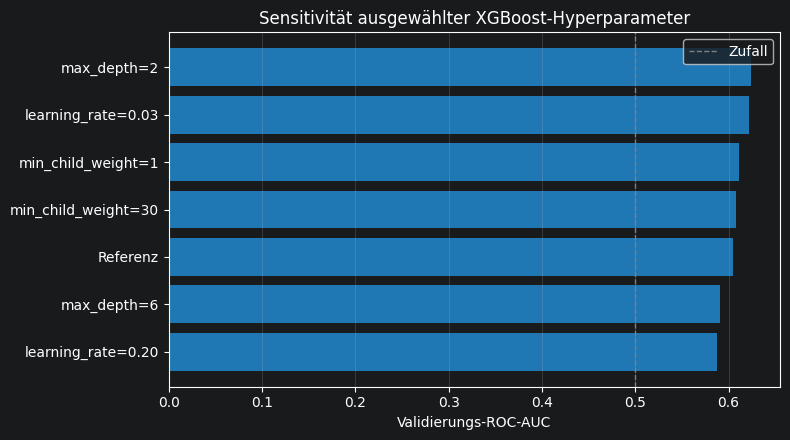

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = sensitivitaet.sort_values("AUC Validierung")
ax.barh(plot_df["Konfiguration"], plot_df["AUC Validierung"], color="tab:blue")
ax.axvline(0.5, linestyle="--", color="grey", linewidth=1, label="Zufall")
ax.set_xlabel("Validierungs-ROC-AUC")
ax.set_title("Sensitivität ausgewählter XGBoost-Hyperparameter")
ax.grid(axis="x", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(ABB_DIR / "xgb_sensitivitaet.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Kompakte Hyperparametersuche

Die Zufallssuche konzentriert sich auf sechs zentrale Parameter. `gamma` und
`reg_alpha` werden nicht zusätzlich aufgenommen, weil ein sehr breiter Suchraum bei nur
20 Ziehungen kaum systematisch abgedeckt werden könnte. Die Optimierung erfolgt anhand
der ROC-AUC und ausschließlich innerhalb der Trainingsdaten.


In [8]:
param_dist = {
    "model__n_estimators": randint(300, 901),
    "model__learning_rate": loguniform(0.02, 0.20),
    "model__max_depth": randint(2, 7),
    "model__min_child_weight": randint(1, 31),
    "model__subsample": uniform(0.60, 0.40),
    "model__colsample_bytree": uniform(0.60, 0.40),
}

X_search, _, y_search, _ = train_test_split(
    X_train,
    y_train,
    train_size=SEARCH_FRAC,
    stratify=y_train,
    random_state=SEED,
)

search_cv = StratifiedKFold(
    n_splits=SEARCH_CV_SPLITS,
    shuffle=True,
    random_state=SEED,
)

search = RandomizedSearchCV(
    estimator=baue_xgb_pipeline(),
    param_distributions=param_dist,
    n_iter=N_ITER,
    scoring="roc_auc",
    cv=search_cv,
    refit=False,
    n_jobs=1,
    random_state=SEED,
    verbose=2,
    return_train_score=True,
)

print(f"Suchmenge: {len(X_search):,} Zeilen")
print(f"Geplante Fits: {N_ITER} × {SEARCH_CV_SPLITS} = {N_ITER * SEARCH_CV_SPLITS}")

t0 = time.perf_counter()
search.fit(X_search, y_search)
suchzeit = time.perf_counter() - t0

print(f"\nSuchzeit: {suchzeit / 60:.1f} min")
print(f"Beste mittlere CV-AUC: {search.best_score_:.4f}")


Suchmenge: 119,042 Zeilen
Geplante Fits: 20 × 3 = 60
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END model__colsample_bytree=0.749816047538945, model__learning_rate=0.1785436060870726, model__max_depth=4, model__min_child_weight=8, model__n_estimators=320, model__subsample=0.6624074561769746; total time=   2.6s
[CV] END model__colsample_bytree=0.749816047538945, model__learning_rate=0.1785436060870726, model__max_depth=4, model__min_child_weight=8, model__n_estimators=320, model__subsample=0.6624074561769746; total time=   2.6s
[CV] END model__colsample_bytree=0.749816047538945, model__learning_rate=0.1785436060870726, model__max_depth=4, model__min_child_weight=8, model__n_estimators=320, model__subsample=0.6624074561769746; total time=   2.7s
[CV] END model__colsample_bytree=0.662397808134481, model__learning_rate=0.022861967752626437, model__max_depth=6, model__min_child_weight=4, model__n_estimators=430, model__subsample=0.608233797718321; total time=   3.6s
[

In [9]:
cv_res = pd.DataFrame(search.cv_results_)
param_spalten = [c for c in cv_res.columns if c.startswith("param_model__")]

top5_suche = (cv_res
    .sort_values("rank_test_score")
    .head(5)[[
        "rank_test_score",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "mean_fit_time",
    ] + param_spalten]
    .reset_index(drop=True))

top5_suche.columns = [c.replace("param_model__", "") for c in top5_suche.columns]
print("Beste Parameterkombination:")
for name, wert in sorted(search.best_params_.items()):
    print(f"  {name.replace('model__', ''):<20} {wert}")

top5_suche.round(4)


Beste Parameterkombination:
  colsample_bytree     0.610167650697638
  learning_rate        0.0256402008378338
  max_depth            2
  min_child_weight     20
  n_estimators         395
  subsample            0.878206434570451


,rank_test_score,mean_train_score,mean_test_score,std_test_score,mean_fit_time,colsample_bytree,learning_rate,max_depth,min_child_weight,n_estimators,subsample
0,1,0.6595,0.6233,0.0070,2.4485,0.6102,0.0256,2,20,395,0.8782
1,2,0.6718,0.6226,0.0068,3.8158,0.8447,0.0203,2,17,774,0.8447
2,3,0.7174,0.6194,0.0065,4.2739,0.8271,0.0215,3,26,855,0.9758
3,4,0.7739,0.6167,0.0067,4.6875,0.6795,0.0203,4,19,892,0.8845
4,5,0.7109,0.6161,0.0050,3.9546,0.9400,0.0563,2,16,802,0.7244


## 9. Finale Bewertung auf dem Testsplit

Erst jetzt werden Baseline und optimiertes XGBoost auf Training plus Validierung gefittet
und auf dem zuvor unberührten Testsplit verglichen. Die Testwerte dürfen nicht zur
nachträglichen Änderung der Hyperparameter verwendet werden.


In [15]:
def trainiere_und_bewerte(name, modell):
    t0 = time.perf_counter()
    modell.fit(X_train_val, y_train_val)
    fit_zeit = time.perf_counter() - t0

    p_train = modell.predict_proba(X_train_val)[:, 1]
    p_test = modell.predict_proba(X_test)[:, 1]
    zeile = {
        "Modell": name,
        "ROC-AUC Train": roc_auc_score(y_train_val, p_train),
        "ROC-AUC Test": roc_auc_score(y_test, p_test),
        "Gini Test": gini(y_test, p_test),
        "Average Precision Test": average_precision_score(y_test, p_test),
        "Train-Test-Abstand": roc_auc_score(y_train_val, p_train) - roc_auc_score(y_test, p_test),
        "Fit-Zeit [s]": fit_zeit,
    }
    return zeile, p_test

beste_params = {
    name.replace("model__", ""): wert
    for name, wert in search.best_params_.items()
}

baseline_final = baue_xgb_pipeline()
xgb_final = baue_xgb_pipeline(**beste_params)

zeile_baseline, p_test_baseline = trainiere_und_bewerte(
    "XGBClassifier (Baseline)", baseline_final
)
zeile_xgb, p_test_xgb = trainiere_und_bewerte(
    "XGBClassifier (optimiert)", xgb_final
)

xgb_test_ergebnisse = pd.DataFrame([zeile_baseline, zeile_xgb])
xgb_test_ergebnisse.round(4)


,Modell,ROC-AUC Train,ROC-AUC Test,Gini Test,Average Precision Test,Train-Test-Abstand,Fit-Zeit [s]
0,XGBClassifier (Baseline),0.7848,0.6208,0.2416,0.0633,0.164,9.6929
1,XGBClassifier (optimiert),0.6401,0.6411,0.2822,0.0668,-0.001,13.6076


### ROC- und Precision-Recall-Kurve


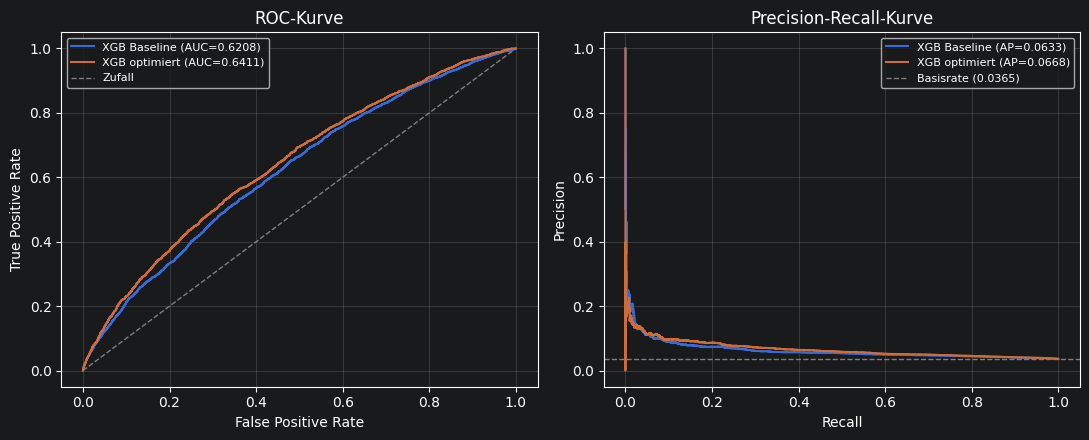

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

for label, proba in [
    ("XGB Baseline", p_test_baseline),
    ("XGB optimiert", p_test_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax1.plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_test, proba):.4f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax2.plot(recall, precision, label=f"{label} (AP={ap:.4f})")

ax1.plot([0, 1], [0, 1], "--", color="grey", linewidth=1, label="Zufall")
ax1.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC-Kurve")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

ax2.axhline(y_test.mean(), linestyle="--", color="grey", linewidth=1,
            label=f"Basisrate ({y_test.mean():.4f})")
ax2.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall-Kurve")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(ABB_DIR / "xgb_roc_und_pr_test.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Gain-basierte Feature Importance

Die Gain-Importance misst, wie stark Splits eines Features durchschnittlich die
Zielfunktion verbessern. Sie zeigt keine Kausalität. Bei korrelierten Merkmalen kann sich
die Importance außerdem auf mehrere Features verteilen; One-Hot-Encoding verteilt sie
zusätzlich auf mehrere Kategorien eines ursprünglichen Merkmals.


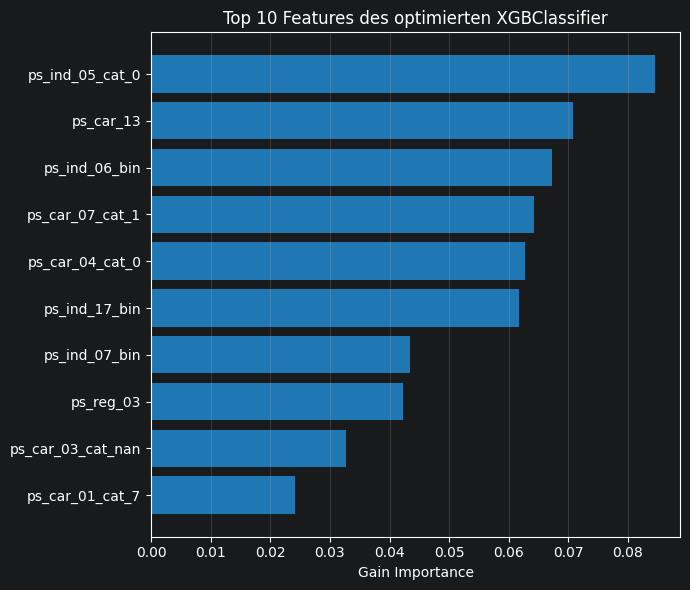

,Feature,Gain Importance
0,ps_ind_05_cat_0,0.0845
1,ps_car_13,0.0708
2,ps_ind_06_bin,0.0673
3,ps_car_07_cat_1,0.0642
4,ps_car_04_cat_0,0.0627
5,ps_ind_17_bin,0.0617
6,ps_ind_07_bin,0.0434
7,ps_reg_03,0.0423
8,ps_car_03_cat_nan,0.0327
9,ps_car_01_cat_7,0.0241


In [17]:
feature_names = xgb_final.named_steps["prep"].get_feature_names_out()
importances = xgb_final.named_steps["model"].feature_importances_

feature_importance = (pd.DataFrame({
    "Feature": feature_names,
    "Gain Importance": importances,
})
.sort_values("Gain Importance", ascending=False)
.reset_index(drop=True))

TOP_N = 10
plot_df = feature_importance.head(TOP_N).sort_values("Gain Importance")

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(plot_df["Feature"], plot_df["Gain Importance"], color="tab:blue")
ax.set_xlabel("Gain Importance")
ax.set_title(f"Top {TOP_N} Features des optimierten XGBClassifier")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(ABB_DIR / "xgb_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

feature_importance.head(TOP_N).round(4)


## 11. Vergleich mit der LogReg und Export

Falls das Ergebnis-CSV des vereinfachten LogReg-Notebooks im gleichen Arbeitsordner
liegt, wird es automatisch ergänzt. Andernfalls bleibt die XGBoost-Tabelle vollständig
nutzbar und kann später mit `pd.concat` erweitert werden.


In [18]:
logreg_pfad = Path("logreg_anwendung_abbildungen") / "logreg_ergebnis.csv"

if logreg_pfad.exists():
    logreg_ergebnis = pd.read_csv(logreg_pfad)
    gemeinsame_spalten = [
        "Modell",
        "ROC-AUC Train",
        "ROC-AUC Test",
        "Gini Test",
        "Average Precision Test",
        "Fit-Zeit [s]",
    ]
    modellvergleich = pd.concat(
        [logreg_ergebnis[gemeinsame_spalten], xgb_test_ergebnisse[gemeinsame_spalten]],
        ignore_index=True,
    )
else:
    print("LogReg-Ergebnisdatei nicht gefunden – zunächst nur XGBoost ausgewiesen.")
    modellvergleich = xgb_test_ergebnisse.copy()

modellvergleich.round(4)


,Modell,ROC-AUC Train,ROC-AUC Test,Gini Test,Average Precision Test,Fit-Zeit [s]
0,Logistische Regression (Baseline),0.6342,0.6371,0.2743,0.0673,11.4370
1,XGBClassifier (Baseline),0.7848,0.6208,0.2416,0.0633,9.6929
2,XGBClassifier (optimiert),0.6401,0.6411,0.2822,0.0668,13.6076


In [20]:
sensitivitaet.to_csv(ABB_DIR / "xgb_sensitivitaet.csv", index=False)
top5_suche.to_csv(ABB_DIR / "xgb_random_search_top5.csv", index=False)
xgb_test_ergebnisse.to_csv(ABB_DIR / "xgb_test_ergebnisse.csv", index=False)
feature_importance.to_csv(ABB_DIR / "xgb_feature_importance.csv", index=False)
modellvergleich.to_csv(ABB_DIR / "modellvergleich_logreg_xgb.csv", index=False)

beste_parameter = pd.DataFrame(
    sorted(beste_params.items()),
    columns=["Hyperparameter", "Wert"],
)
beste_parameter.to_csv(ABB_DIR / "xgb_beste_hyperparameter.csv", index=False)

print(modellvergleich.round(4).to_string(index=False))
print(f"\nErgebnisse gespeichert unter: {ABB_DIR.resolve()}")


                           Modell  ROC-AUC Train  ROC-AUC Test  Gini Test  Average Precision Test  Fit-Zeit [s]
Logistische Regression (Baseline)         0.6342        0.6371     0.2743                  0.0673       11.4370
         XGBClassifier (Baseline)         0.7848        0.6208     0.2416                  0.0633        9.6929
        XGBClassifier (optimiert)         0.6401        0.6411     0.2822                  0.0668       13.6076

Ergebnisse gespeichert unter: C:\Users\ericz\ADA Projekt\xgbclassifier_anwendung_abbildungen


## Kurze Schlussinterpretation

Für die Bewertung sind drei Fragen entscheidend:

1. Liegt die Test-ROC-AUC beziehungsweise der Gini des optimierten XGBoost über der LogReg?
2. Ist der Gewinn größer als die Streuung der Cross-Validation?
3. Bleibt der Train-Test-Abstand vertretbar oder erkauft XGBoost den Gewinn durch
   deutlich stärkeres Overfitting?

Ein kleiner AUC-Gewinn kann trotzdem relevant sein, sollte aber gemeinsam mit Laufzeit,
Stabilität und Modellkomplexität interpretiert werden.
